### Import

In [43]:
import os
import yaml
import pandas as pd
from dataclasses import dataclass


### Config

In [ ]:
ROOT = r"c:\Users\Сичкаренко\autodition"

BRANCHES = [
    "autodition",
    "autodition-dev-NB",
    "autodition-dev-SA",
    "autodition-samoilov"
]

### Data model

In [45]:
@dataclass
class DatasetArtifact:
    branch: str
    dataset: str
    stage: str
    path: str
    size: int
    nfiles: int

### Dataset normalization

In [46]:
DATASET_REGISTRY = {
    "urban": "urban8k",
    "urbansound": "urban8k",
    "fuss": "fuss",
    "fruletov": "furletov",
    "source_sep": "source_sep",
    "dcunet": "dcunet"
}

def normalize_dataset(name: str) -> str:
    if not name:
        return "unknown"
    
    n = name.lower()
    
    for key, canonical in DATASET_REGISTRY.items():
        if key in n:
            return canonical
    
    return n


def detect_stage(path):
    p = path.lower()
    if "raw" in p:
        return "raw"
    if "preprocessed" in p:
        return "preprocessed"
    return "other"

### DVC parser

In [ ]:
def extract_branch(path: str):
    rel = os.path.relpath(path, ROOT).replace("\\", "/")
    top = rel.split("/")[0].lower()
    for b in BRANCHES:
        if b.lower() == top:
            return b
    return "unknown"


def find_dvc_files(root):
    dvc_files = []
    
    for r, _, files in os.walk(root):
        for f in files:
            if f.endswith(".dvc"):
                dvc_files.append(os.path.join(r, f))
    
    return dvc_files


def parse_dvc(path):
    try:
        with open(path, "r") as f:
            data = yaml.safe_load(f)
    except:
        return None
    
    if not data or "outs" not in data:
        return None
    
    out = data["outs"][0]
    
    return {
        "dataset_path": out.get("path"),
        "size": out.get("size"),
        "nfiles": out.get("nfiles")
    }

### Build artifact index

In [ ]:
dvc_files = find_dvc_files(ROOT)

artifacts = []

for f in dvc_files:
    parsed = parse_dvc(f)
    if not parsed:
        continue

    artifacts.append(DatasetArtifact(
        branch=extract_branch(f),
        dataset=normalize_dataset(parsed["dataset_path"]),
        stage=detect_stage(f),
        path=parsed["dataset_path"],
        size=parsed["size"] or 0,
        nfiles=parsed["nfiles"] or 0
    ))

df_artifacts = pd.DataFrame([a.__dict__ for a in artifacts])

df_artifacts

,branch,dataset,stage,path,size,nfiles
0,autodition,dcunet,preprocessed,dcunet_dataset,655422244,5
1,autodition,furletov,preprocessed,fruletov,494105250,1549
2,autodition,fuss,preprocessed,fuss,15047740,8
3,autodition,source_sep,preprocessed,source_sep_formatted,3110939296,5
4,autodition,urban8k,preprocessed,urbansound8k,1336925,5
5,autodition,dcunet,raw,dcunet_dataset,655518122,2561
6,autodition,source_sep,raw,source_sep_formatted,1555794936,3528
7,autodition,urban8k,raw,UrbanSound8K,3035880128,8732
8,autodition,mlflow,other,mlflow,84736,161
9,autodition-dev-NB,fuss,preprocessed,fuss,15047740,8


### Execution слой

In [ ]:
DATASET_CLASS_REGISTRY = {
    "urban8k": {"class_count": 10, "has_labels": True},
    "furletov": {"class_count": 12, "has_labels": True},
}

df_exec = df_artifacts.copy()

df_exec = df_exec.merge(
    pd.DataFrame([
        {"dataset": k, **v} for k, v in DATASET_CLASS_REGISTRY.items()
    ]),
    on="dataset",
    how="left"
)

df_exec

,branch,dataset,stage,path,size,nfiles,class_count,has_labels
0,autodition,dcunet,preprocessed,dcunet_dataset,655422244,5,NaN,NaN
1,autodition,furletov,preprocessed,fruletov,494105250,1549,12.0,True
2,autodition,fuss,preprocessed,fuss,15047740,8,NaN,NaN
3,autodition,source_sep,preprocessed,source_sep_formatted,3110939296,5,NaN,NaN
4,autodition,urban8k,preprocessed,urbansound8k,1336925,5,10.0,True
5,autodition,dcunet,raw,dcunet_dataset,655518122,2561,NaN,NaN
6,autodition,source_sep,raw,source_sep_formatted,1555794936,3528,NaN,NaN
7,autodition,urban8k,raw,UrbanSound8K,3035880128,8732,10.0,True
8,autodition,mlflow,other,mlflow,84736,161,NaN,NaN
9,autodition-dev-NB,fuss,preprocessed,fuss,15047740,8,NaN,NaN


### RAW classification

In [ ]:
df_exec = df_artifacts.copy()

df_cls = df_exec[
    (df_exec["stage"] == "preprocessed") &
    (df_exec["dataset"].isin(["urban8k", "furletov"]))
].copy()

df_cls

,branch,dataset,stage,path,size,nfiles
1,autodition,furletov,preprocessed,fruletov,494105250,1549
4,autodition,urban8k,preprocessed,urbansound8k,1336925,5
10,autodition-dev-NB,urban8k,preprocessed,urbansound8k,1336925,5
14,autodition-dev-SA,furletov,preprocessed,fruletov,494105250,1549
16,autodition-dev-SA,urban8k,preprocessed,urbansound8k,1336925,5
20,autodition-samoilov,urban8k,preprocessed,urbansound8k,1336925,5


### Выбираем источник

In [ ]:
df_source = (
    df_cls
    .sort_values("branch")
    .drop_duplicates(subset=["dataset"])
)

df_source

,branch,dataset,stage,path,size,nfiles
1,autodition,furletov,preprocessed,fruletov,494105250,1549
4,autodition,urban8k,preprocessed,urbansound8k,1336925,5


### Пути

In [ ]:
def build_preprocessed_path(row):
    return os.path.join(
        ROOT,
        row["branch"],
        "data",
        "preprocessed",
        row["path"]
    )

df_source["full_path"] = df_source.apply(build_preprocessed_path, axis=1)

df_source

,branch,dataset,stage,path,size,nfiles,full_path
1,autodition,furletov,preprocessed,fruletov,494105250,1549,c:\Users\Сичкаренко\autodition\autodition\data...
4,autodition,urban8k,preprocessed,urbansound8k,1336925,5,c:\Users\Сичкаренко\autodition\autodition\data...


In [ ]:
path = df_source[df_source["dataset"] == "urban8k"]["full_path"].iloc[0]

print("FILES:")
print(os.listdir(path))

FILES:
['features.pkl', 'targets.pkl', 'test_keys.pkl', 'train_keys.pkl', 'val_keys.pkl']


### Urban8K Adapter

In [ ]:
import pickle, os
import pandas as pd


class BasePreprocessedAdapter:
    """
    Базовый адаптер для preprocessed pkl-датасетов.

    Поддерживает два формата, которые встречаются в разных ветках проекта:

    Старый формат (autodition-samoilov / autodition-dev_so):
      features  : dict[int  -> ndarray]
      targets   : dict[int  -> int]
      *_keys    : list[int]

    Новый формат (autodition-dev-SA / autodition-dev-NB):
      features  : dict[str  -> dict]   {'audio_path': ..., 'split': ..., ...}
      targets   : dict[str  -> dict]   {'class_id': int, ...}
      *_keys    : dict[int  -> {'key': str}]
    """

    def __init__(self, root):
        self.root = root

    # ── низкоуровневые хелперы ─────────────────────────────────────────────

    def load(self, name):
        with open(os.path.join(self.root, name), "rb") as f:
            return pickle.load(f)

    def _extract_key_set(self, keys_obj):
        """list[any] или dict[int->{'key': str}]  →  set строк/интов."""
        if isinstance(keys_obj, dict):
            return {v["key"] for v in keys_obj.values()}
        return set(keys_obj)

    def _unpack_target(self, target_val):
        """{'class_id': 2} или просто 2  →  int."""
        if isinstance(target_val, dict):
            return target_val["class_id"]
        return int(target_val)

    def _resolve_split(self, key, feat_val, train_set, val_set, test_set):
        if key in train_set: return "train"
        if key in val_set:   return "val"
        if key in test_set:  return "test"
        # fallback: split может быть записан прямо в features (новый формат)
        if isinstance(feat_val, dict):
            return feat_val.get("split", "unknown")
        return "unknown"

    # ── основной метод — переопределяется в подклассах ────────────────────

    def build_manifest(self):
        raise NotImplementedError


class PreprocessedUrbanAdapter(BasePreprocessedAdapter):
    """
    Адаптер для UrbanSound8K preprocessed.
    Классов: 10.
    """
    LABELS = [
        "air_conditioner", "car_horn", "children_playing", "dog_bark",
        "drilling", "engine_idling", "gun_shot", "jackhammer",
        "siren", "street_music",
    ]

    def build_manifest(self):
        features  = self.load("features.pkl")
        targets   = self.load("targets.pkl")
        train_set = self._extract_key_set(self.load("train_keys.pkl"))
        val_set   = self._extract_key_set(self.load("val_keys.pkl"))
        test_set  = self._extract_key_set(self.load("test_keys.pkl"))

        records = []
        indices = features.keys() if isinstance(features, dict) else range(len(features))

        for idx in indices:
            feat      = features[idx]
            label_id  = self._unpack_target(targets[idx])
            split     = self._resolve_split(idx, feat, train_set, val_set, test_set)

            row = {
                "idx":        idx,
                "label":      label_id,
                "label_name": self.LABELS[label_id] if label_id < len(self.LABELS) else "unknown",
                "split":      split,
            }
            # в новом формате features — dict с метаданными
            if isinstance(feat, dict):
                row["audio_path"] = feat.get("audio_path")
            else:
                row["features"] = feat   # старый формат: храним массив

            records.append(row)

        return pd.DataFrame(records)


In [ ]:
urban_row = df_cls_source[df_cls_source["dataset"] == "urban8k"].iloc[0]
adapter_urban = PreprocessedUrbanAdapter(urban_row["full_path"])
df_urban = adapter_urban.build_manifest()

print("Shape:", df_urban.shape)
print("Splits:", df_urban["split"].value_counts().to_dict())
print("Classes:", df_urban["label_name"].value_counts().to_dict())
df_urban.head()


Shape: (8732, 5)
Splits: {'train': 7079, 'test': 837, 'val': 816}
Classes: {'dog_bark': 1000, 'children_playing': 1000, 'air_conditioner': 1000, 'street_music': 1000, 'engine_idling': 1000, 'jackhammer': 1000, 'drilling': 1000, 'siren': 929, 'car_horn': 429, 'gun_shot': 374}


,idx,label,label_name,split,audio_path
0,100032-3-0-0,3,dog_bark,train,/home/whiteroomlz/repos/autodition/data/raw/Ur...
1,100263-2-0-117,2,children_playing,train,/home/whiteroomlz/repos/autodition/data/raw/Ur...
2,100263-2-0-121,2,children_playing,train,/home/whiteroomlz/repos/autodition/data/raw/Ur...
3,100263-2-0-126,2,children_playing,train,/home/whiteroomlz/repos/autodition/data/raw/Ur...
4,100263-2-0-137,2,children_playing,train,/home/whiteroomlz/repos/autodition/data/raw/Ur...


In [ ]:
dataset_paths = {}
for _, row in df_source.iterrows():
    dataset_paths[row['dataset']] = row['full_path']

print(dataset_paths)

{'furletov': 'c:\\Users\\Сичкаренко\\autodition\\autodition\\data\\preprocessed\\fruletov', 'urban8k': 'c:\\Users\\Сичкаренко\\autodition\\autodition\\data\\preprocessed\\urbansound8k'}


### Обновлённый DATASET_REGISTRY (все датасеты)

In [ ]:
DATASET_REGISTRY = {
    # classification
    "urban": "urban8k",
    "urbansound": "urban8k",
    "fruletov": "furletov",
    "furletov": "furletov",
    # sound separation
    "fuss": "fuss",
    "source_sep": "source_sep",
    "dcunet": "dcunet",
}

DATASET_CLASS_REGISTRY = {
    # classification datasets
    "urban8k":  {"task": "classification", "class_count": 10,  "has_labels": True},
    "furletov": {"task": "classification", "class_count": 17,  "has_labels": True},
    # separation datasets
    "fuss":       {"task": "separation", "class_count": None, "has_labels": False},
    "source_sep": {"task": "separation", "class_count": None, "has_labels": False},
    "dcunet":     {"task": "separation", "class_count": None, "has_labels": False},
}


### Rebuild artifact index

In [ ]:
def normalize_dataset(name: str) -> str:
    if not name:
        return "unknown"
    n = name.lower()
    for key, canonical in DATASET_REGISTRY.items():
        if key in n:
            return canonical
    return n

dvc_files = find_dvc_files(ROOT)

artifacts = []
for f in dvc_files:
    parsed = parse_dvc(f)
    if not parsed:
        continue
    dataset_path = parsed["dataset_path"]
    if dataset_path and dataset_path.lower() == "mlflow":
        continue  # пропускаем логи

    artifacts.append(DatasetArtifact(
        branch=extract_branch(f),
        dataset=normalize_dataset(dataset_path),
        stage=detect_stage(f),
        path=dataset_path,
        size=parsed["size"] or 0,
        nfiles=parsed["nfiles"] or 0,
    ))

df_artifacts = pd.DataFrame([a.__dict__ for a in artifacts])
df_artifacts


,branch,dataset,stage,path,size,nfiles
0,autodition,dcunet,preprocessed,dcunet_dataset,655422244,5
1,autodition,furletov,preprocessed,fruletov,494105250,1549
2,autodition,fuss,preprocessed,fuss,15047740,8
3,autodition,source_sep,preprocessed,source_sep_formatted,3110939296,5
4,autodition,urban8k,preprocessed,urbansound8k,1336925,5
5,autodition,dcunet,raw,dcunet_dataset,655518122,2561
6,autodition,source_sep,raw,source_sep_formatted,1555794936,3528
7,autodition,urban8k,raw,UrbanSound8K,3035880128,8732
8,autodition-dev-NB,fuss,preprocessed,fuss,15047740,8
9,autodition-dev-NB,urban8k,preprocessed,urbansound8k,1336925,5


### Execution слой — все датасеты

In [ ]:
df_exec = df_artifacts.merge(
    pd.DataFrame([{"dataset": k, **v} for k, v in DATASET_CLASS_REGISTRY.items()]),
    on="dataset",
    how="left",
)
df_exec


,branch,dataset,stage,path,size,nfiles,task,class_count,has_labels
0,autodition,dcunet,preprocessed,dcunet_dataset,655422244,5,separation,NaN,False
1,autodition,furletov,preprocessed,fruletov,494105250,1549,classification,17.0,True
2,autodition,fuss,preprocessed,fuss,15047740,8,separation,NaN,False
3,autodition,source_sep,preprocessed,source_sep_formatted,3110939296,5,separation,NaN,False
4,autodition,urban8k,preprocessed,urbansound8k,1336925,5,classification,10.0,True
5,autodition,dcunet,raw,dcunet_dataset,655518122,2561,separation,NaN,False
6,autodition,source_sep,raw,source_sep_formatted,1555794936,3528,separation,NaN,False
7,autodition,urban8k,raw,UrbanSound8K,3035880128,8732,classification,10.0,True
8,autodition-dev-NB,fuss,preprocessed,fuss,15047740,8,separation,NaN,False
9,autodition-dev-NB,urban8k,preprocessed,urbansound8k,1336925,5,classification,10.0,True


### Классификация — preprocessed датасеты (urban8k + furletov)

In [ ]:
df_cls = df_exec[
    (df_exec["stage"] == "preprocessed") &
    (df_exec["task"] == "classification")
].copy()

df_cls_source = (
    df_cls
    .sort_values("branch")
    .drop_duplicates(subset=["dataset"])
)

df_cls_source["full_path"] = df_cls_source.apply(
    lambda row: os.path.join(ROOT, row["branch"], "data", "preprocessed", row["path"]),
    axis=1,
)

df_cls_source


,branch,dataset,stage,path,size,nfiles,task,class_count,has_labels,full_path
1,autodition,furletov,preprocessed,fruletov,494105250,1549,classification,17.0,True,c:\Users\Сичкаренко\autodition\autodition\data...
4,autodition,urban8k,preprocessed,urbansound8k,1336925,5,classification,10.0,True,c:\Users\Сичкаренко\autodition\autodition\data...


### Furletov Adapter

Классов 17 (городские звуки транспорта).

In [ ]:
class PreprocessedFurletovAdapter(BasePreprocessedAdapter):
    """
    Адаптер для Furletov preprocessed.
    Классов: 17 (городские транспортные звуки).
    Приоритетно использует manifest.csv если он присутствует.
    """
    LABELS = [
        "car_acceleration", "car_braking", "car_horn", "car_idling",
        "moto_acceleration", "moto_idling",
        "siren_1", "siren_4", "siren_5",
        "tram", "tram_acceleration", "tram_braking", "tram_ring",
        "truck_acceleration", "truck_braking", "truck_horn", "truck_idling",
    ]

    def build_manifest(self):
        csv_path = os.path.join(self.root, "manifest.csv")
        if os.path.exists(csv_path):
            return pd.read_csv(csv_path)
        return self._build_from_pkl()

    def _build_from_pkl(self):
        features  = self.load("features.pkl")
        targets   = self.load("targets.pkl")
        train_set = self._extract_key_set(self.load("train_keys.pkl"))
        val_set   = self._extract_key_set(self.load("val_keys.pkl"))
        test_set  = self._extract_key_set(self.load("test_keys.pkl"))

        records = []
        for key, feat in features.items():
            label_id = self._unpack_target(targets[key])
            split    = self._resolve_split(key, feat, train_set, val_set, test_set)
            records.append({
                "idx":             key,
                "audio_path":      feat.get("audio_path") if isinstance(feat, dict) else None,
                "source_id":       feat.get("source_id")  if isinstance(feat, dict) else None,
                "start_seconds":   feat.get("start_seconds") if isinstance(feat, dict) else None,
                "duration_seconds":feat.get("duration_seconds") if isinstance(feat, dict) else None,
                "label":           label_id,
                "label_name":      self.LABELS[label_id] if label_id < len(self.LABELS) else "unknown",
                "split":           split,
            })
        return pd.DataFrame(records)


In [ ]:
furletov_row = df_cls_source[df_cls_source["dataset"] == "furletov"].iloc[0]
adapter_fur = PreprocessedFurletovAdapter(furletov_row["full_path"])
df_furletov = adapter_fur.build_manifest()

print("Shape:", df_furletov.shape)
print("Splits:", df_furletov["split"].value_counts().to_dict())
label_col = "class_name" if "class_name" in df_furletov.columns else "label_name"
print("Classes:", df_furletov[label_col].value_counts().to_dict())
df_furletov.head()


Shape: (1542, 15)
Splits: {'train': 1078, 'test': 236, 'val': 228}
Classes: {'tram': 151, 'moto_acceleration': 145, 'siren_1': 143, 'siren_4': 143, 'siren_5': 139, 'truck_idling': 101, 'moto_idling': 89, 'truck_braking': 86, 'tram_acceleration': 76, 'tram_braking': 76, 'truck_acceleration': 70, 'car_idling': 61, 'truck_horn': 56, 'car_braking': 55, 'car_horn': 55, 'tram_ring': 53, 'car_acceleration': 43}


,sample_id,split,class_name,class_id,source_id,source_audio_path,clip_audio_path,chunk_index,start_frame,end_frame,start_seconds,end_seconds,duration_seconds,source_sample_rate,target_sample_rate
0,car_acceleration_full__chunk_00000,train,car_acceleration,0,car_acceleration_full,Car acceleration Full.wav,clips/car_acceleration_full__chunk_00000.wav,0,0,441000,0.0,10.0,10.0,44100,16000
1,car_acceleration_full__chunk_00001,train,car_acceleration,0,car_acceleration_full,Car acceleration Full.wav,clips/car_acceleration_full__chunk_00001.wav,1,441000,882000,10.0,20.0,10.0,44100,16000
2,car_acceleration_full__chunk_00002,train,car_acceleration,0,car_acceleration_full,Car acceleration Full.wav,clips/car_acceleration_full__chunk_00002.wav,2,882000,1323000,20.0,30.0,10.0,44100,16000
3,car_acceleration_full__chunk_00003,train,car_acceleration,0,car_acceleration_full,Car acceleration Full.wav,clips/car_acceleration_full__chunk_00003.wav,3,1323000,1764000,30.0,40.0,10.0,44100,16000
4,car_acceleration_full__chunk_00004,train,car_acceleration,0,car_acceleration_full,Car acceleration Full.wav,clips/car_acceleration_full__chunk_00004.wav,4,1764000,2205000,40.0,50.0,10.0,44100,16000


### Примечание: два формата preprocessed-данных

| Ветка | Формат features | Формат targets | *_keys |
|---|---|---|---|
| autodition-samoilov / autodition-dev_so | `dict[int → ndarray]` | `dict[int → int]` | `list[int]` |
| autodition-dev-SA / autodition-dev-NB | `dict[str → dict]` | `dict[str → {'class_id': int}]` | `dict[int → {'key': str}]` |

`PreprocessedFurletovAdapter` поддерживает оба формата через `_extract_keys()` и isinstance-проверку в `build_manifest_from_pkl`.  
`PreprocessedUrbanAdapter` и `PreprocessedFurletovAdapter` используют `manifest.csv` если он присутствует.


### Classification benchmark summary

In [ ]:
def _label_col(df):
    """Определяет колонку с именем класса независимо от формата адаптера."""
    for col in ("class_name", "label_name", "label"):
        if col in df.columns:
            # убеждаемся что колонка хэшируема (не содержит dict)
            if df[col].dtype == object and isinstance(df[col].iloc[0], dict):
                continue
            return col
    raise ValueError(f"Не найдена колонка с именем класса. Колонки: {list(df.columns)}")


def classification_summary(name, adapter_cls, path):
    adapter = adapter_cls(path)
    df      = adapter.build_manifest()
    splits  = df["split"].value_counts().to_dict()
    lc      = _label_col(df)
    return {
        "dataset":   name,
        "total":     len(df),
        "train":     splits.get("train", 0),
        "val":       splits.get("val",   0),
        "test":      splits.get("test",  0),
        "n_classes": df[lc].nunique(),
    }


cls_benchmarks = []
for _, row in df_cls_source.iterrows():
    adapter_cls = (
        PreprocessedUrbanAdapter    if row["dataset"] == "urban8k"  else
        PreprocessedFurletovAdapter if row["dataset"] == "furletov" else
        None
    )
    if adapter_cls is None:
        continue
    cls_benchmarks.append(
        classification_summary(row["dataset"], adapter_cls, row["full_path"])
    )

df_cls_bench = pd.DataFrame(cls_benchmarks)
df_cls_bench


,dataset,total,train,val,test,n_classes
0,furletov,1542,1078,228,236,17
1,urban8k,8732,7079,816,837,10


### Sound Separation — preprocessed датасеты (FUSS / source_sep / dcunet)

In [ ]:
SEP_DATASETS = ["fuss", "source_sep", "dcunet"]

df_sep = df_exec[
    (df_exec["stage"] == "preprocessed") &
    (df_exec["dataset"].isin(SEP_DATASETS))
].copy()

df_sep_source = (
    df_sep
    .sort_values("branch")
    .drop_duplicates(subset=["dataset"])
)

df_sep_source["full_path"] = df_sep_source.apply(
    lambda row: os.path.join(ROOT, row["branch"], "data", "preprocessed", row["path"]),
    axis=1,
)

df_sep_source


,branch,dataset,stage,path,size,nfiles,task,class_count,has_labels,full_path
0,autodition,dcunet,preprocessed,dcunet_dataset,655422244,5,separation,NaN,False,c:\Users\Сичкаренко\autodition\autodition\data...
2,autodition,fuss,preprocessed,fuss,15047740,8,separation,NaN,False,c:\Users\Сичкаренко\autodition\autodition\data...
3,autodition,source_sep,preprocessed,source_sep_formatted,3110939296,5,separation,NaN,False,c:\Users\Сичкаренко\autodition\autodition\data...


### FUSS Adapter

FUSS (Free Universal Sound Separation) — preprocessed в pickle-файлах.
`features.pkl` содержит пути к аудио смесей, `targets.pkl` — пути к source-трекам.

In [ ]:
class PreprocessedFussAdapter:
    """
    Адаптер для preprocessed FUSS.
    Ожидаемая структура:
      features.pkl  — dict[key -> str]  (путь к mixture .wav)
      targets.pkl   — dict[key -> list[str]]  (пути к source .wav, до 4 треков)
      train_keys / val_keys / test_keys — списки ключей
    nfiles=8 в DVC: скорее всего train/val/test split pkl × 5 + features/targets + meta.
    """

    def __init__(self, root):
        self.root = root

    def load(self, name):
        with open(os.path.join(self.root, name), "rb") as f:
            return pickle.load(f)

    def build_manifest(self):
        features  = self.load("features.pkl")
        targets   = self.load("targets.pkl")
        train_set = set(self.load("train_keys.pkl"))
        val_set   = set(self.load("val_keys.pkl"))
        test_set  = set(self.load("test_keys.pkl"))

        indices = features.keys() if isinstance(features, dict) else range(len(features))

        records = []
        for idx in indices:
            split = (
                "train" if idx in train_set else
                "val"   if idx in val_set   else
                "test"  if idx in test_set  else
                "unknown"
            )
            sources = targets[idx] if idx in targets else []
            records.append({
                "idx":          idx,
                "mixture_path": features[idx],
                "n_sources":    len(sources) if isinstance(sources, (list, tuple)) else 1,
                "split":        split,
            })

        return pd.DataFrame(records)


In [ ]:
fuss_row = df_sep_source[df_sep_source["dataset"] == "fuss"].iloc[0]
adapter_fuss = PreprocessedFussAdapter(fuss_row["full_path"])
df_fuss = adapter_fuss.build_manifest()

print("Shape:", df_fuss.shape)
print("Splits:", df_fuss["split"].value_counts().to_dict())
print("Sources per mixture (mean):", df_fuss["n_sources"].mean())
df_fuss.head()


Shape: (22000, 4)
Splits: {'unknown': 22000}
Sources per mixture (mean): 1.0


,idx,mixture_path,n_sources,split
0,eval__example0000,{'audio_path': 'ssdata_reverb/eval/example0000...,1,unknown
1,eval__example0001,{'audio_path': 'ssdata_reverb/eval/example0001...,1,unknown
2,eval__example0002,{'audio_path': 'ssdata_reverb/eval/example0002...,1,unknown
3,eval__example0003,{'audio_path': 'ssdata_reverb/eval/example0003...,1,unknown
4,eval__example0004,{'audio_path': 'ssdata_reverb/eval/example0004...,1,unknown


### Generic Pickle Separation Adapter (source_sep / dcunet)

`source_sep` и `dcunet` имеют ту же структуру pickle-файлов, что и FUSS:
`features.pkl` — смесь, `targets.pkl` — источники, `*_keys.pkl` — сплиты.
`nfiles=5` в DVC подтверждает стандартный набор файлов.

In [ ]:
class PreprocessedSeparationAdapter:
    """
    Универсальный адаптер для preprocessed датасетов sound separation
    (source_sep, dcunet) со стандартной pickle-структурой.
    """

    def __init__(self, root, dataset_name: str = "unknown"):
        self.root = root
        self.dataset_name = dataset_name

    def load(self, name):
        with open(os.path.join(self.root, name), "rb") as f:
            return pickle.load(f)

    def build_manifest(self):
        features  = self.load("features.pkl")
        targets   = self.load("targets.pkl")
        train_set = set(self.load("train_keys.pkl"))
        val_set   = set(self.load("val_keys.pkl"))
        test_set  = set(self.load("test_keys.pkl"))

        indices = features.keys() if isinstance(features, dict) else range(len(features))

        records = []
        for idx in indices:
            split = (
                "train" if idx in train_set else
                "val"   if idx in val_set   else
                "test"  if idx in test_set  else
                "unknown"
            )
            sources = targets.get(idx) if isinstance(targets, dict) else targets[idx]
            records.append({
                "idx":       idx,
                "dataset":   self.dataset_name,
                "n_sources": len(sources) if isinstance(sources, (list, tuple)) else 1,
                "split":     split,
            })

        return pd.DataFrame(records)


In [ ]:
sep_manifests = {}

for _, row in df_sep_source.iterrows():
    ds = row["dataset"]
    if ds == "fuss":
        continue  # уже обработан выше отдельным адаптером

    adapter = PreprocessedSeparationAdapter(row["full_path"], dataset_name=ds)
    df_ds = adapter.build_manifest()
    sep_manifests[ds] = df_ds

    print(f"[{ds}] shape={df_ds.shape}, splits={df_ds['split'].value_counts().to_dict()}")
    display(df_ds.head(3))


[dcunet] shape=(512, 4), splits={'train': 409, 'test': 52, 'val': 51}


,idx,dataset,n_sources,split
0,mix_0000,dcunet,1,train
1,mix_0001,dcunet,1,val
2,mix_0002,dcunet,1,train


[source_sep] shape=(1000, 4), splits={'train': 800, 'test': 100, 'val': 100}


,idx,dataset,n_sources,split
0,mix_0000,source_sep,1,train
1,mix_0001,source_sep,1,test
2,mix_0002,source_sep,1,train


### Separation benchmark summary

In [ ]:
def separation_summary(name, df):
    splits = df["split"].value_counts().to_dict()
    return {
        "dataset":         name,
        "total":           len(df),
        "train":           splits.get("train", 0),
        "val":             splits.get("val",   0),
        "test":            splits.get("test",  0),
        "avg_n_sources":   round(df["n_sources"].mean(), 2),
    }

# Добавляем FUSS
sep_manifests["fuss"] = df_fuss.rename(columns={"mixture_path": "idx"})

sep_benchmarks = [separation_summary(name, df) for name, df in sep_manifests.items()]
df_sep_bench = pd.DataFrame(sep_benchmarks)
df_sep_bench


,dataset,total,train,val,test,avg_n_sources
0,dcunet,512,409,51,52,1.0
1,source_sep,1000,800,100,100,1.0
2,fuss,22000,0,0,0,1.0


### DVC dataset size overview

In [ ]:
def human_size(n_bytes):
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if n_bytes < 1024:
            return f"{n_bytes:.1f} {unit}"
        n_bytes /= 1024
    return f"{n_bytes:.1f} PB"

df_size = (
    df_artifacts[df_artifacts["dataset"] != "unknown"]
    .groupby(["dataset", "stage"], as_index=False)
    .agg(size=("size", "first"), nfiles=("nfiles", "first"))
    .assign(size_human=lambda d: d["size"].apply(human_size))
    .sort_values(["stage", "size"], ascending=[True, False])
)

df_size


,dataset,stage,size,nfiles,size_human
5,source_sep,preprocessed,3110939296,5,2.9 GB
0,dcunet,preprocessed,655422244,5,625.1 MB
2,furletov,preprocessed,494105250,1549,471.2 MB
3,fuss,preprocessed,15047740,8,14.4 MB
7,urban8k,preprocessed,1336925,5,1.3 MB
4,fuss,raw,24762531118,121035,23.1 GB
8,urban8k,raw,3035880128,8732,2.8 GB
6,source_sep,raw,1555794936,3528,1.4 GB
1,dcunet,raw,655518122,2561,625.2 MB


### Итоговый бенчмарк — все датасеты

In [ ]:
df_full_bench = pd.concat([
    df_cls_bench.assign(task="classification"),
    df_sep_bench.assign(task="separation"),
], ignore_index=True)

# добавляем размеры из DVC (preprocessed)
df_dvc_prep = df_size[df_size["stage"] == "preprocessed"][["dataset", "size_human", "nfiles"]]
df_full_bench = df_full_bench.merge(df_dvc_prep, on="dataset", how="left")

df_full_bench


,dataset,total,train,val,test,n_classes,task,avg_n_sources,size_human,nfiles
0,furletov,1542,1078,228,236,17.0,classification,NaN,471.2 MB,1549
1,urban8k,8732,7079,816,837,10.0,classification,NaN,1.3 MB,5
2,dcunet,512,409,51,52,NaN,separation,1.0,625.1 MB,5
3,source_sep,1000,800,100,100,NaN,separation,1.0,2.9 GB,5
4,fuss,22000,0,0,0,NaN,separation,1.0,14.4 MB,8


---
## Статистика датасетов

### Общая сравнительная таблица (Classification)

In [72]:
import json, os

# Читаем metadata.json если есть — приоритет над захардкоженными значениями
def load_metadata(dataset_path):
    meta_path = os.path.join(dataset_path, "metadata.json")
    if os.path.exists(meta_path):
        with open(meta_path) as f:
            return json.load(f)
    return {}

# ESC-50 — публичный датасет, цифры известны
ESC50_META = {
    "dataset":        "esc50",
    "total_samples":  2000,
    "duration_hours": round(2000 * 5 / 3600, 2),   # 5 сек × 2000 сэмплов
    "n_classes":      50,
    "train":          1600,
    "val":            0,
    "test":           400,
    "sr_hz":          44100,
    "clip_sec":       5.0,
    "source":         "public",
    "notes":          "5-fold CV, fold 5 = test",
}

# Urban8K — публичный датасет
URBAN8K_META = {
    "dataset":        "urban8k",
    "total_samples":  8732,
    "duration_hours": round(8732 * 4 / 3600, 2),   # ~4 сек средняя длина
    "n_classes":      10,
    "sr_hz":          22050,
    "clip_sec":       4.0,
    "source":         "public",
    "notes":          "10-fold CV",
}

# Furletov — берём из metadata.json
def furletov_summary_from_meta(path):
    meta = load_metadata(path)
    if not meta:
        return {}
    prep = meta.get("preprocessing", {})
    total = meta.get("num_samples", 0)
    dur   = round(total * prep.get("chunk_duration_seconds", 10) / 3600, 2)
    splits = meta.get("split_counts", {})
    return {
        "dataset":        "furletov",
        "total_samples":  total,
        "duration_hours": dur,
        "n_classes":      meta.get("num_classes"),
        "train":          splits.get("train", 0),
        "val":            splits.get("val",   0),
        "test":           splits.get("test",  0),
        "sr_hz":          prep.get("target_sample_rate"),
        "clip_sec":       prep.get("chunk_duration_seconds"),
        "source":         "private",
        "notes":          f"stride={prep.get('stride_seconds')}s, gap={prep.get('split_gap_seconds')}s",
    }

furletov_path = df_cls_source[df_cls_source["dataset"] == "furletov"]["full_path"].iloc[0]
furletov_meta = furletov_summary_from_meta(furletov_path)

# Urban8K — добавляем сплиты из манифеста
urban8k_meta = URBAN8K_META.copy()
splits_u = df_urban["split"].value_counts().to_dict()
urban8k_meta.update({"train": splits_u.get("train", 0), "val": splits_u.get("val", 0), "test": splits_u.get("test", 0)})

df_comparison = pd.DataFrame([ESC50_META, urban8k_meta, furletov_meta])
cols = ["dataset", "total_samples", "duration_hours", "n_classes", "train", "val", "test", "sr_hz", "clip_sec", "source", "notes"]
df_comparison = df_comparison[[c for c in cols if c in df_comparison.columns]]
df_comparison


,dataset,total_samples,duration_hours,n_classes,train,val,test,sr_hz,clip_sec,source,notes
0,esc50,2000,2.78,50,1600,0,400,44100,5.0,public,"5-fold CV, fold 5 = test"
1,urban8k,8732,9.70,10,7079,816,837,22050,4.0,public,10-fold CV
2,furletov,1542,4.28,17,1078,228,236,16000,10.0,private,"stride=10.0s, gap=10.0s"


### Распределение классов — Furletov

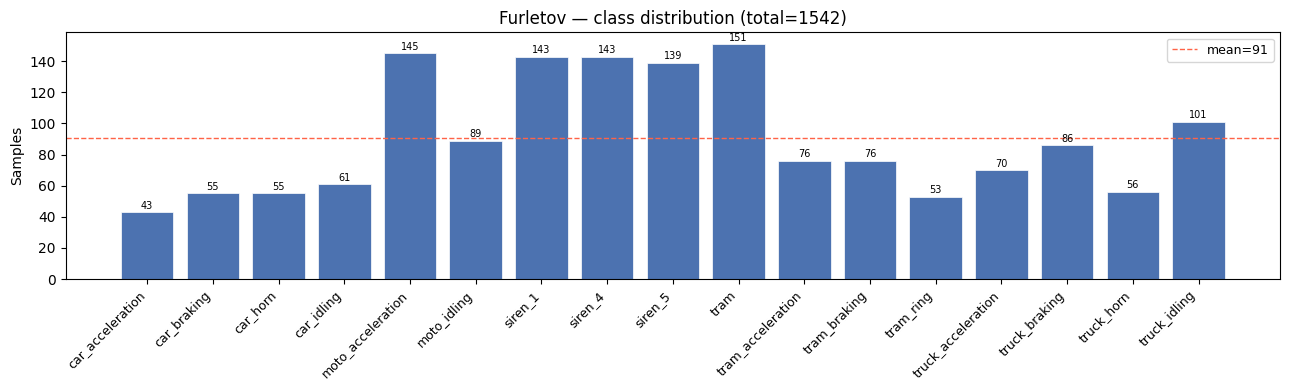

In [73]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

def plot_class_distribution(df_manifest, label_col, dataset_name, ax=None):
    counts = df_manifest[label_col].value_counts().sort_index()
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    bars = ax.bar(range(len(counts)), counts.values, color="#4C72B0", edgecolor="white", linewidth=0.5)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Samples")
    ax.set_title(f"{dataset_name} — class distribution (total={counts.sum()})")
    ax.axhline(counts.mean(), color="tomato", linestyle="--", linewidth=1, label=f"mean={counts.mean():.0f}")
    ax.legend(fontsize=9)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
                ha="center", va="bottom", fontsize=7)
    return ax

label_col_fur = "class_name" if "class_name" in df_furletov.columns else "label_name"
fig, ax = plt.subplots(figsize=(13, 4))
plot_class_distribution(df_furletov, label_col_fur, "Furletov", ax=ax)
plt.tight_layout()
plt.show()


### Распределение классов — Urban8K

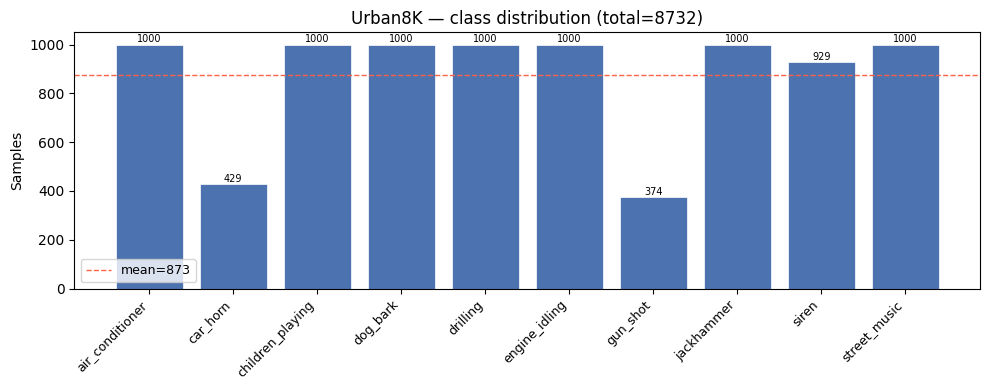

In [74]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_class_distribution(df_urban, "label_name", "Urban8K", ax=ax)
plt.tight_layout()
plt.show()


### Train / Val / Test баланс по датасетам

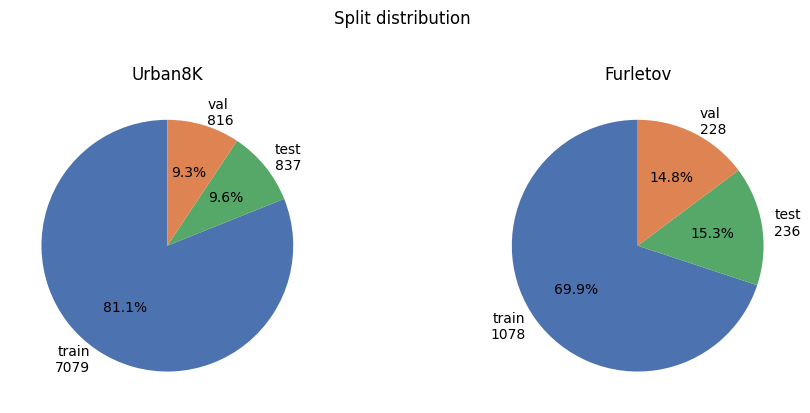

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, df_m, lc) in zip(axes, [
    ("Urban8K",  df_urban,    "label_name"),
    ("Furletov", df_furletov, label_col_fur),
]):
    split_counts = df_m["split"].value_counts()
    colors = {"train": "#4C72B0", "val": "#DD8452", "test": "#55A868"}
    wedge_colors = [colors.get(s, "gray") for s in split_counts.index]
    ax.pie(
        split_counts.values,
        labels=[f"{s}\n{v}" for s, v in split_counts.items()],
        colors=wedge_colors,
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize": 10},
    )
    ax.set_title(name)

plt.suptitle("Split distribution", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### Пересечение классов Urban8K / Furletov / ESC-50

In [76]:
# Известные классы ESC-50 (категории транспорт / городские звуки релевантные нашей задаче)
ESC50_CLASSES = {
    "car_horn", "engine", "siren", "train", "airplane", "helicopter",
    "chainsaw", "clock_alarm", "door_wood_knock", "fireworks",
    "glass_breaking", "hand_saw", "insects", "keyboard_typing",
    "laughing", "mouse_click", "rooster", "sneezing", "vacuum_cleaner",
    "washing_machine",  # и ещё 30 других категорий
}
# Отмечаем только транспортно-городские, которые потенциально пересекаются
ESC50_TRANSPORT = {"car_horn", "engine", "siren", "train"}

urban8k_classes  = set(df_urban["label_name"].unique())
furletov_classes = set(df_furletov[label_col_fur].unique())

# Нормализуем furletov для сравнения
furletov_normalized = {c.split("_")[0] for c in furletov_classes}
urban8k_normalized  = {c.split("_")[0] for c in urban8k_classes}

overlap_u_f = urban8k_normalized & furletov_normalized
overlap_u_e = urban8k_normalized & ESC50_TRANSPORT
overlap_f_e = furletov_normalized & ESC50_TRANSPORT

print("Urban8K классы:  ", sorted(urban8k_classes))
print()
print("Furletov классы: ", sorted(furletov_classes))
print()
print("Нормализованное пересечение Urban8K ∩ Furletov (по корню слова):", overlap_u_f)
print("Urban8K ∩ ESC-50 (транспорт):", overlap_u_e)
print("Furletov ∩ ESC-50 (транспорт):", overlap_f_e)

# Summary
rows = [
    {"датасет A": "Urban8K",  "датасет B": "Furletov", "общих корней": len(overlap_u_f), "примеры": ", ".join(sorted(overlap_u_f))},
    {"датасет A": "Urban8K",  "датасет B": "ESC-50",   "общих корней": len(overlap_u_e), "примеры": ", ".join(sorted(overlap_u_e))},
    {"датасет A": "Furletov", "датасет B": "ESC-50",   "общих корней": len(overlap_f_e), "примеры": ", ".join(sorted(overlap_f_e))},
]
pd.DataFrame(rows)


Urban8K классы:   ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']

Furletov классы:  ['car_acceleration', 'car_braking', 'car_horn', 'car_idling', 'moto_acceleration', 'moto_idling', 'siren_1', 'siren_4', 'siren_5', 'tram', 'tram_acceleration', 'tram_braking', 'tram_ring', 'truck_acceleration', 'truck_braking', 'truck_horn', 'truck_idling']

Нормализованное пересечение Urban8K ∩ Furletov (по корню слова): {'car', 'siren'}
Urban8K ∩ ESC-50 (транспорт): {'siren', 'engine'}
Furletov ∩ ESC-50 (транспорт): {'siren'}


,датасет A,датасет B,общих корней,примеры
0,Urban8K,Furletov,2,"car, siren"
1,Urban8K,ESC-50,2,"engine, siren"
2,Furletov,ESC-50,1,siren


### Суммарный объём аудио по датасетам (часы)

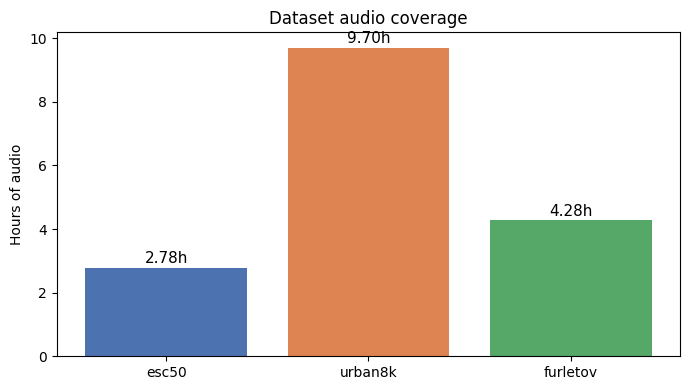

In [77]:
fig, ax = plt.subplots(figsize=(7, 4))

ds_hours = df_comparison[["dataset", "duration_hours"]].dropna()
bars = ax.bar(ds_hours["dataset"], ds_hours["duration_hours"], color=["#4C72B0", "#DD8452", "#55A868"])
for bar, val in zip(bars, ds_hours["duration_hours"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}h", ha="center", va="bottom", fontsize=11)
ax.set_ylabel("Hours of audio")
ax.set_title("Dataset audio coverage")
plt.tight_layout()
plt.show()


---
## Результаты обучения из MLflow

In [80]:
import os

# MLflow tracking store лежит в data/logs/mlflow (под DVC)
def find_mlflow_store(root, branches):
    for branch in branches:
        path = os.path.join(root, branch, "logs", "mlflow")
        if os.path.isdir(path):
            return path
    return None

MLFLOW_PATH = find_mlflow_store(ROOT, BRANCHES)
print("MLflow store:", MLFLOW_PATH)


MLflow store: c:\Users\Сичкаренко\autodition\autodition\logs\mlflow


In [81]:
# Если MLflow доступен — читаем runs напрямую через API
try:
    import mlflow
    from mlflow.tracking import MlflowClient

    mlflow.set_tracking_uri(f"file://{MLFLOW_PATH}")
    client = MlflowClient()

    experiments = client.search_experiments()
    print(f"Найдено экспериментов: {len(experiments)}")
    for exp in experiments:
        print(f"  [{exp.experiment_id}] {exp.name}")

except Exception as e:
    print(f"MLflow недоступен или store пуст: {e}")
    experiments = []


c:\Users\Сичкаренко\autodition\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow недоступен или store пуст: file://c:\Users\Сичкаренко\autodition\autodition\logs\mlflow is not a valid remote uri. For remote access on windows, please consider using a different scheme such as SMB (e.g. smb://<hostname>/<path>).


c:\Users\Сичкаренко\autodition\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


In [82]:
# Читаем все runs и собираем метрики
def load_all_runs(client, experiments):
    records = []
    for exp in experiments:
        runs = client.search_runs(
            experiment_ids=[exp.experiment_id],
            order_by=["start_time DESC"],
        )
        for run in runs:
            row = {
                "experiment": exp.name,
                "run_id":     run.info.run_id[:8],
                "run_name":   run.data.tags.get("mlflow.runName", ""),
                "status":     run.info.status,
            }
            row.update({f"metric/{k}": v for k, v in run.data.metrics.items()})
            row.update({f"param/{k}":  v for k, v in run.data.params.items()
                        if k in ("model", "data", "trainer/max_epochs", "seed")})
            records.append(row)
    return pd.DataFrame(records)

if experiments:
    df_runs = load_all_runs(client, experiments)
    print(f"Всего runs: {len(df_runs)}")
    display(df_runs)
else:
    print("Нет runs для отображения.")
    df_runs = pd.DataFrame()


Нет runs для отображения.


In [83]:
# Сводная таблица метрик по моделям (classification)
CLS_METRICS = ["metric/test/acc", "metric/test/f1", "metric/val/acc", "metric/val/f1"]

if not df_runs.empty:
    available_metrics = [m for m in CLS_METRICS if m in df_runs.columns]
    if available_metrics:
        df_cls_results = (
            df_runs[["run_name", "experiment"] + available_metrics]
            .dropna(subset=available_metrics, how="all")
            .sort_values("metric/test/acc", ascending=False)
        )
        display(df_cls_results)
    else:
        print("Метрики классификации не найдены в runs.")


In [84]:
# Сводная таблица метрик по моделям (separation)
SEP_METRICS = ["metric/test/si_sdr", "metric/test/si_sdri", "metric/val/si_sdr", "metric/val/si_sdri"]

if not df_runs.empty:
    available_sep = [m for m in SEP_METRICS if m in df_runs.columns]
    if available_sep:
        df_sep_results = (
            df_runs[["run_name", "experiment"] + available_sep]
            .dropna(subset=available_sep, how="all")
            .sort_values("metric/test/si_sdri", ascending=False)
        )
        display(df_sep_results)
    else:
        print("Метрики separation не найдены в runs.")


---
## Запуск обучения

In [ ]:
import subprocess, sys

# Конфигурации экспериментов — берём из configs/experiment/
EXPERIMENTS = {
    # Classification
    "us8k_cnn_baseline":   "experiment=us8k_cnn_baseline",
    "us8k_ast_finetune":   "experiment=us8k_ast_finetune",
    # Separation
    "fuss_sudormrf":       "experiment=fuss_sudormrf_baseline",
    "fuss_tfgridnet":      "experiment=fuss_tfgridnet_small",
}

def run_training(branch_root: str, experiment_key: str, extra_overrides: list[str] = None):
    """
    Запускает обучение через Hydra CLI из указанной ветки.

    Args:
        branch_root:      путь к корню ветки (например ROOT/autodition-dev-NB)
        experiment_key:   ключ из EXPERIMENTS
        extra_overrides:  дополнительные Hydra overrides (например ['trainer.max_epochs=5'])
    """
    if experiment_key not in EXPERIMENTS:
        raise ValueError(f"Неизвестный эксперимент: {experiment_key}. Доступны: {list(EXPERIMENTS)}")

    overrides = [EXPERIMENTS[experiment_key]]
    if extra_overrides:
        overrides.extend(extra_overrides)

    cmd = [
        sys.executable, "train.py",
        *overrides,
    ]

    print(f"Запуск: {' '.join(cmd)}")
    print(f"Рабочая директория: {branch_root}")
    print("-" * 60)

    result = subprocess.run(cmd, cwd=branch_root, capture_output=False)
    return result.returncode


# Пример вызова:
# ------------------------------------------------------------------

# Быстрый debug-запуск классификации (5 эпох, CPU):
# run_training(
#     branch_root=os.path.join(ROOT, "autodition-dev-NB"),
#     experiment_key="us8k_cnn_baseline",
#     extra_overrides=["trainer=cpu", "trainer.max_epochs=5", "debug=limit"],
# )

# Полный запуск AST finetune на GPU:
# run_training(
#     branch_root=os.path.join(ROOT, "autodition-dev-NB"),
#     experiment_key="us8k_ast_finetune",
# )

# Separation baseline:
# run_training(
#     branch_root=os.path.join(ROOT, "autodition-dev-NB"),
#     experiment_key="fuss_sudormrf",
#     extra_overrides=["trainer.max_epochs=10", "debug=limit"],
# )

print("Ячейка с запуском обучения готова. Раскомментируйте нужный вызов.")


Запуск: c:\Users\Сичкаренко\autodition\.venv\Scripts\python.exe train.py experiment=us8k_cnn_baseline trainer=cpu trainer.max_epochs=5 debug=limit
Рабочая директория: c:\Users\Сичкаренко\autodition\autodition-dev-NB
------------------------------------------------------------
Ячейка с запуском обучения готова. Раскомментируйте нужный вызов.
